**1. Import Libraries**

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

**2. Load YOUR Dataset**

In [16]:
df = pd.read_csv("../data/raw/Crop Prediction dataset.csv")

df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Temperature,Humidity,Soil_Moisture,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0


**3. Structure Overview**

In [17]:
print("Shape:", df.shape)

Shape: (49999, 10)


In [18]:
df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop',
       'Temperature', 'Humidity', 'Soil_Moisture', 'Area', 'Production'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49999 entries, 0 to 49998
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   State_Name     49999 non-null  object 
 1   District_Name  49999 non-null  object 
 2   Crop_Year      49999 non-null  int64  
 3   Season         49999 non-null  object 
 4   Crop           49999 non-null  object 
 5   Temperature    49999 non-null  int64  
 6   Humidity       49999 non-null  int64  
 7   Soil_Moisture  49999 non-null  int64  
 8   Area           49999 non-null  float64
 9   Production     49784 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 3.8+ MB


**4. Missing Values Check**

In [20]:
df.isnull().sum()

State_Name         0
District_Name      0
Crop_Year          0
Season             0
Crop               0
Temperature        0
Humidity           0
Soil_Moisture      0
Area               0
Production       215
dtype: int64

In [21]:
df = df.fillna(df.median(numeric_only=True))

**5. Rename Columns**

In [22]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['state_name', 'district_name', 'crop_year', 'season', 'crop',
       'temperature', 'humidity', 'soil_moisture', 'area', 'production'],
      dtype='object')

**Target Column Identification**

In [23]:
df.head()

,state_name,district_name,crop_year,season,crop,temperature,humidity,soil_moisture,area,production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,36,35,45,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,37,40,46,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,36,41,50,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,37,42,55,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,36,40,54,720.0,165.0


**Target Distribution**

In [24]:
df['crop'].value_counts()

crop
Rice                 3853
Maize                3249
Moong(Green Gram)    2084
Dry chillies         1595
Arhar/Tur            1578
                     ... 
Grapes                 17
Varagu                 13
Peas  (vegetable)       3
other fibres            2
Guar seed               1
Name: count, Length: 80, dtype: int64

**Numerical Feature Analysis**

In [25]:
df.describe()

,crop_year,temperature,humidity,soil_moisture,area,production
count,49999.000000,49999.000000,49999.000000,49999.000000,49999.000000,4.999900e+04
mean,2005.879138,34.445489,44.776116,53.110502,7363.389469,4.114278e+05
std,5.106092,3.498524,6.662406,5.258764,27927.935789,1.229959e+07
min,1997.000000,25.000000,35.000000,45.000000,0.200000,0.000000e+00
25%,2002.000000,34.000000,40.000000,50.000000,76.000000,8.800000e+01
50%,2006.000000,36.000000,42.000000,54.000000,436.000000,6.384400e+02
75%,2010.000000,36.000000,50.000000,55.000000,2546.500000,5.556000e+03
max,2014.000000,37.000000,55.000000,62.000000,877029.000000,7.801620e+08


**Correlation Analysis**

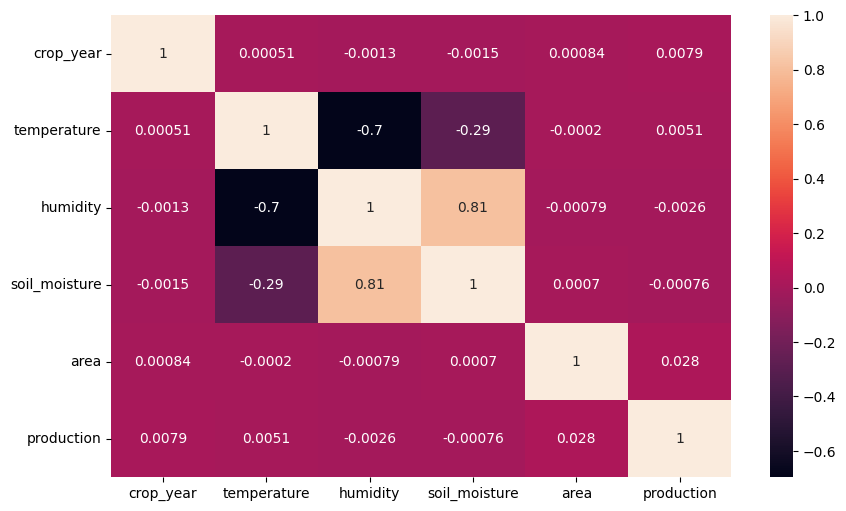

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

**10. Feature Distribution**

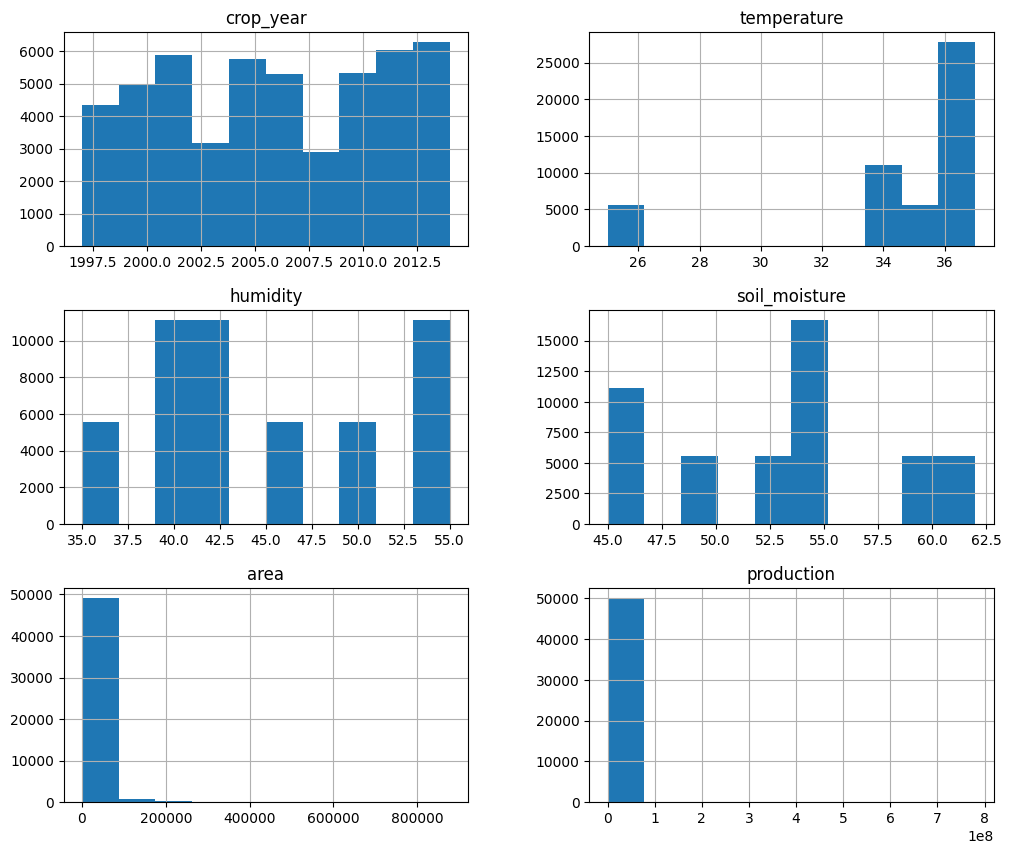

In [27]:
df.hist(figsize=(12,10))
plt.show()

**Class Balance Check**

In [28]:
df['crop'].value_counts(normalize=True)

crop
Rice                 0.077062
Maize                0.064981
Moong(Green Gram)    0.041681
Dry chillies         0.031901
Arhar/Tur            0.031561
                       ...   
Grapes               0.000340
Varagu               0.000260
Peas  (vegetable)    0.000060
other fibres         0.000040
Guar seed            0.000020
Name: proportion, Length: 80, dtype: float64